# Mie soluzioni agli esercizi della lezione 3
## Esercizio 1 - MLP netowrk con TensorFlow primitives

In [337]:
import tensorflow as tf
import numpy as np

tf.random.set_seed(0)

class Modello(tf.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._w = []
        self._b = []
        self._a = []
        self._n_layers = 0

    # weights and bias will be assigned at random if none are specified
    def add_layer(self, in_features, out_features, weights = [], bias = [], a = []):
        if weights == []:
            weights = tf.random.normal([in_features, out_features])
        if bias == []:
            bias = tf.random.normal([out_features])

        if a != []:
            self._a.append(tf.Variable(a))

        self._n_layers += 1
        self._w.append(tf.Variable(weights))
        self._b.append(tf.Variable(bias))

    def inference(self, x):
        features = x
        for i in range(self._n_layers - 1):
            features = tf.sigmoid(tf.add(tf.matmul(features, self._w[i]), self._b[i]))

        # Output layer is linear
        features = tf.matmul(features, self._w[-1]) + self._b[-1]

        return features
    
    def __call__(self, x):
        return self.inference(x)
    
    def get_weights_bias(self):
        return self._w, self._b
    
    def loss(self, y_pred, y_true):
        return tf.reduce_mean(tf.square(y_true - y_pred))
    
    # completely broken. Does NOT work!
    def backpropagation(self, y_true, learning_rate):
        # iterare su tutti i sample!
        for y_sample in y_true:
            self._a = []  # Clear activations for this sample
            
            with tf.GradientTape(persistent=True) as tape:
                # Forward pass through network to record operations
                y_pred = self.inference(tf.reshape(y_sample, [1, -1]))
                delta_l = y_pred - tf.reshape(y_sample, [1, -1])
                
            # Compute gradients for output layer
            dw_l = tape.gradient(delta_l, self._w[-1])
            db_l = tape.gradient(delta_l, self._b[-1])
            
            if dw_l is not None:
                self._w[-1].assign_sub(learning_rate * dw_l)
            if db_l is not None:
                self._b[-1].assign_sub(learning_rate * db_l)

            # Backpropagate through hidden layers
            for l in range(1, self._n_layers - 1):
                # Sigmoid derivative: sigmoid(x) * (1 - sigmoid(x))
                sigmoid_deriv = self._a[-l-1] * (1 - self._a[-l-1])
                delta_l = (delta_l @ tf.transpose(self._w[-l])) * sigmoid_deriv
                
                # Compute gradients with correct shapes
                dw_l = tf.transpose(self._a[-l-2]) @ delta_l
                db_l = tf.reduce_sum(delta_l, axis=0, keepdims=True)
                
                self._w[-l-1].assign_sub(learning_rate * dw_l)
                self._b[-l-1].assign_sub(learning_rate * db_l)
        
    '''
    def backpropagation(self, y_true, learning_rate):
        # iterare su tutti i sample!
        for y_sample in y_true:
            delta_l = self._a[-1] - y_sample
            
            # Aggiorna i pesi 
            t = tf.GradientTape()
            dw_l, db_l = t.gradient(delta_l, [self._w[-1], self._b[-1]])
            self._w[-1] -= learning_rate*dw_l
            self._b[-1] -= learning_rate*db_l

            for l in range(1, self._n_layers-1):
                delta_l = (self._w[ - l] @ delta_l) * (self._a[-l-1] - self._a[-l-1] *self._a[-l-1])
                dw_l, db_l = t.gradient(delta_l, [self._w[-l-1], self._b[-l-1]])

                self._w[- l - 1] -= learning_rate*dw_l
                self._b[-l-1] -= learning_rate*db_l
    '''
        

n_input = 1
n_hidden_1 = 5
n_hidden_2 = 2
n_output = 1

x1 = np.linspace(-2, 2, 10, dtype=np.float32).reshape(-1,1) 
# dove reshape(x,y) con x = -1 permette di calcolare il numero di righe dato un numero di colonne y e un qualche numero di elementi
# infatti voglio un vettore colonna

model = Modello()

model.add_layer(n_input, n_hidden_1)
model.add_layer(n_hidden_1, n_hidden_2)
model.add_layer(n_hidden_2, n_output)

ypred = model.inference(x1)

ypred


<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.6356413 ],
       [1.5432107 ],
       [1.4098082 ],
       [1.2388794 ],
       [1.0577219 ],
       [0.90039253],
       [0.78264034],
       [0.7014245 ],
       [0.6468698 ],
       [0.60973847]], dtype=float32)>

In [ ]:
model2 = tf.keras.Sequential()

model2.add(tf.keras.layers.Input(shape=(n_input,)))
model2.add(tf.keras.layers.Dense(n_hidden_1, activation="sigmoid"))
model2.add(tf.keras.layers.Dense(n_hidden_2, activation="sigmoid"))
model2.add(tf.keras.layers.Dense(n_output, activation="linear"))


weights, biases = model.get_weights_bias()

model2.set_weights(
    [weights[0], biases[0],
     weights[1], biases[1],
     weights[2], biases[2]]
)

ypred2 = model2(x1)


# Verifichiamo che i modelli corrispondano (delta = 0)
delta = ypred - ypred2
delta

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)>

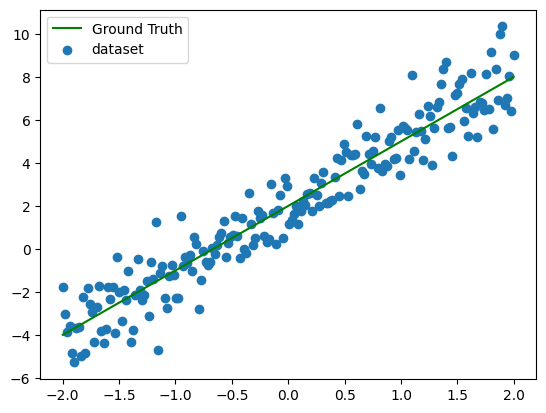

In [339]:
import matplotlib.pyplot as plt

# Ground Truth
def f(x):
    return 3 * x + 2

# Dataset
x = np.linspace(-2, 2, 200, dtype=np.float32).reshape(-1,1)
y = tf.Variable(tf.add(f(x), tf.random.normal(shape=x.shape)))

# Plotting 
plt.plot(x, f(x), color="green", label="Ground Truth")
plt.scatter(x, y, label="dataset")
plt.legend()

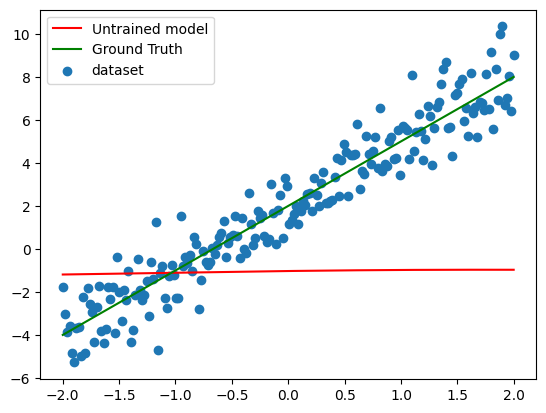

In [340]:
# Initialize model and plot untrained model
model_f = Modello()

# The neural network will have 1 input feature, 2 hidden layers with 5 neurons each 
# and 1 output layer with 1 output feature
model_f.add_layer(in_features=1, out_features=5)
model_f.add_layer(in_features=5, out_features=5)
model_f.add_layer(in_features=5, out_features=1)


y_untrained = model_f(x)

# Plotting untrained model
plt.plot(x, y_untrained, color="red", label="Untrained model")
plt.plot(x, f(x), color="green", label="Ground Truth")
plt.scatter(x, y, label="dataset")
plt.legend()

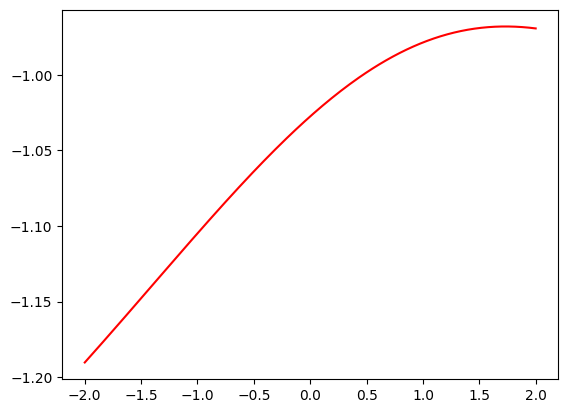

In [341]:
plt.plot(x, y_untrained, color="red", label="Untrained model")

delete that shit lets follow the exercise 

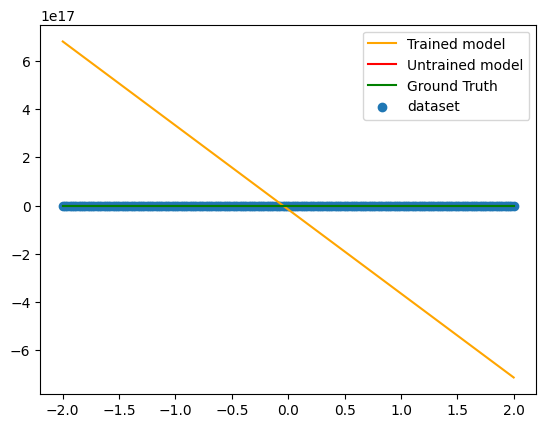

In [342]:
learning_rate = 0.71
epochs = 10

weights = []
biases = []

class Modello2():
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._w = tf.Variable(1.)
        self._b = tf.Variable(0.)


    def __call__(self, x):
        return self._w * x + self._b
    
    def loss(self, y_pred, y_true):
        return tf.reduce_sum(tf.square(y_true - y_pred))

model_1_layer = Modello2()


def train(modello : Modello2, x, y, learning_rate=.1):
    with tf.GradientTape() as tape:
        inference = modello(x)
        current_loss = modello.loss(inference, y)
    
        dw, db = tape.gradient(current_loss, [modello._w, modello._b])

        modello._w.assign_sub(dw * learning_rate)
        modello._b.assign_sub(db * learning_rate)

for i in range(epochs):
    train(model_1_layer, x, y)
    weights.append(model_1_layer._w)
    biases.append(model_1_layer._b)
    current_loss = model_1_layer.loss(model_1_layer(x), y)


plt.plot(x, model_1_layer(x), label="Trained model", color="orange")
plt.plot(x, y_untrained, color="red", label="Untrained model")
plt.plot(x, f(x), color="green", label="Ground Truth")
plt.scatter(x, y, label="dataset")
plt.legend()
